In [22]:
import os
import sys
sys.path.append(os.path.abspath("../src"))
from optimization_logic import *

import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

#Plotting styles
# plt.style.use('ggplot')
plt.rcParams.update(
{"figure.figsize": (12, 5),
#  'font.family': 'serif',
"text.usetex": False,
"axes.titlesize" : 12,
"axes.labelsize" : 10,
# "axes.labelweight" : "bold",
"lines.linewidth": 1,
"lines.markersize" : 5,
"legend.fontsize": 8,
"legend.title_fontsize" : 9,
"xtick.labelsize" : 8,
"ytick.labelsize" : 8})


In [5]:
SIZE = 100               # MWh - default 56.4
POWER_UP = 50            # MW - default 49, 
POWER_DOWN  = 50         # MW - default 49

RTE = 0.88                                # round trip efficiency
CHARGE_EFFICIENCY = np.sqrt(RTE)          #default = sqrt(RTE)
DISCHARGE_EFFICIENCY = np.sqrt(RTE)       #default = sqrt(RTE)

MAX_THROUGHPUT_CYCLES = 2                 # count - default 2.3
THROUGHPUT_SIZE = SIZE                    # MWh
TSTEP = 1                                 # default = 1 for hourly DA market

###############################
#      script technicals      #
###############################

SOLUTION_TIME_LIMIT_SEC = 30  # default 30
INTEGER_PN = False            # default True

###############################
#      DA scpecifics          #
###############################

MANUAL_SOC_MIN = 0           # MWh 
MANUAL_SOC_MAX = SIZE         # MWh

INIT_SOC = 0        # MWh, default = size/2 
END_SOC = 0         # MWh, default = None
end_soc_limit_type = 'equal_to'

###############################
#    Simulation specifics     #
###############################

assume_perfect_foresight = True

###############################
#           Plotting          #
###############################

show_daily_plots = True

###############################
#           Logging           #
###############################

save_setpoint_log = False
save_daily_log = False
save_path = '/simulation_logs/'
save_name_prefix = f'martina_{SIZE}mwh_{POWER_DOWN}mw'


settlement_freq = {0.25: "15min", 0.5: "30min", 1: "H"}

In [6]:
os.getcwd()

'C:\\Users\\Martina\\Downloads\\2025-QUANT-INTERNSHIP-MARTINA-20250203T124011Z-001\\2025-QUANT-INTERNSHIP-MARTINA\\project\\task2_week2\\notebooks'

In [9]:
data_files_path = os.getcwd()+'/'
file_name = '../src/data/processed/gb_epex_da_actuals.csv'
main_data = pd.read_csv(data_files_path+'/'+file_name)

In [10]:
main=pd.read_csv('../src/data/processed/reference_day_table.csv')
is_missing_val=main.isnull().sum()
print(is_missing_val)

date                     0
closest_reference_day    0
euclidean_distance       0
dtype: int64


In [11]:
price_data = pd.read_csv('../data/raw/gb_meteo_da_price_forecast.csv')
price_data.tail()

,Timestamp start (Europe/Brussels),Timestamp end (Europe/Brussels),Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh),dtbe,dtutc
38203,01/02/2025 22:45,01/02/2025 23:00,97.87,2025-02-01 22:45:00+01:00,2025-02-01 21:45:00+00:00
38204,01/02/2025 23:00,01/02/2025 23:15,90.09,2025-02-01 23:00:00+01:00,2025-02-01 22:00:00+00:00
38205,01/02/2025 23:15,01/02/2025 23:30,90.09,2025-02-01 23:15:00+01:00,2025-02-01 22:15:00+00:00
38206,01/02/2025 23:30,01/02/2025 23:45,90.09,2025-02-01 23:30:00+01:00,2025-02-01 22:30:00+00:00
38207,01/02/2025 23:45,02/02/2025 00:00,90.09,2025-02-01 23:45:00+01:00,2025-02-01 22:45:00+00:00


In [20]:
cl_price_data= price_data.rename(columns={"Timestamp start (Europe/Brussels)": "timestamp_start", "Timestamp end (Europe/Brussels)": "timestamp_end", "Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)":"price_avg_forecast_da"})
cl_price_data.head()

,timestamp_start,timestamp_end,price_avg_forecast_da,dtbe,dtutc
0,01/01/2024 00:00,01/01/2024 00:15,45.38,2024-01-01 00:00:00+01:00,2023-12-31 23:00:00+00:00
1,01/01/2024 00:15,01/01/2024 00:30,45.38,2024-01-01 00:15:00+01:00,2023-12-31 23:15:00+00:00
2,01/01/2024 00:30,01/01/2024 00:45,45.38,2024-01-01 00:30:00+01:00,2023-12-31 23:30:00+00:00
3,01/01/2024 00:45,01/01/2024 01:00,45.38,2024-01-01 00:45:00+01:00,2023-12-31 23:45:00+00:00
4,01/01/2024 01:00,01/01/2024 01:15,43.90,2024-01-01 01:00:00+01:00,2024-01-01 00:00:00+00:00


In [18]:
cl_price_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38208 entries, 0 to 38207
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp start     38208 non-null  object 
 1   Timestamp end       38208 non-null  object 
 2   Price AVG forecast  38208 non-null  float64
 3   dtbe                38208 non-null  object 
 4   dtutc               38208 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1.5+ MB


In [25]:
cl_price_data['timestamp_start'] = pd.to_datetime(cl_price_data.timestamp_start, utc=True).dt.date
cl_price_data['timestamp_end'] = pd.to_datetime(cl_price_data.timestamp_end, utc=True).dt.date
cl_price_data['dtbe'] = pd.to_datetime(cl_price_data.dtbe, utc=True).dt.date
cl_price_data['dtutc'] = pd.to_datetime(cl_price_data.dtutc, utc=True).dt.date

cl_price_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38208 entries, 0 to 38207
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp_start        38208 non-null  object 
 1   timestamp_end          38208 non-null  object 
 2   price_avg_forecast_da  38208 non-null  float64
 3   dtbe                   38208 non-null  object 
 4   dtutc                  38208 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1.5+ MB


In [26]:
print(cl_price_data['dtbe'].head(10))


0    2023-12-31
1    2023-12-31
2    2023-12-31
3    2023-12-31
4    2024-01-01
5    2024-01-01
6    2024-01-01
7    2024-01-01
8    2024-01-01
9    2024-01-01
Name: dtbe, dtype: object


In [27]:
cl_price_data.head()

,timestamp_start,timestamp_end,price_avg_forecast_da,dtbe,dtutc
0,2024-01-01,2024-01-01,45.38,2023-12-31,2023-12-31
1,2024-01-01,2024-01-01,45.38,2023-12-31,2023-12-31
2,2024-01-01,2024-01-01,45.38,2023-12-31,2023-12-31
3,2024-01-01,2024-01-01,45.38,2023-12-31,2023-12-31
4,2024-01-01,2024-01-01,43.90,2024-01-01,2024-01-01


In [13]:

data = pd.read_csv('../src/data/processed/processed_data.csv', parse_dates=['dtcet'])

# Preview the dataset
print(data.head())



                       dtcet  demand_National Demand Outturn (INDO) - GB (MW)  \
0  2024-06-01 00:00:00+02:00                                          20349.0   
1  2024-06-01 01:00:00+02:00                                          19447.5   
2  2024-06-01 02:00:00+02:00                                          18827.5   
3  2024-06-01 03:00:00+02:00                                          18030.0   
4  2024-06-01 04:00:00+02:00                                          17463.0   

   demand_National Demand Forecast (NDF) - GB (MW)  \
0                                          20098.0   
1                                          19365.0   
2                                          18495.5   
3                                          18031.0   
4                                          17487.5   

   price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)  \
0                                              68.78                         
1                               

In [15]:
features = [
    'demand_National Demand Forecast (NDF) - GB (MW)',  
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)', 
    'wind_wind_fc_meteo_mw', 
    'solar_solar_fc_meteo_mw'  
]


In [16]:
data.rename(columns={
    'demand_National Demand Forecast (NDF) - GB (MW)': 'demand',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)': 'price',
    'wind_wind_fc_meteo_mw': 'wind',
    'solar_solar_fc_meteo_mw': 'solar'
}, inplace=True)



In [17]:
data.head()

,dtcet,demand_National Demand Outturn (INDO) - GB (MW),demand,price,wind_wind_fc_p10_meteo_mw,wind,wind_wind_fc_p90_meteo_mw,wind_wind_installed_capacity_mw,solar_solar_fc_p10_meteo_mw,solar,solar_solar_fc_p90_meteo_mw,solar_solar_installed_capacity_mw
0,2024-06-01 00:00:00+02:00,20349.0,20098.0,68.78,6906.9775,8027.880,9148.7775,25583.0,0.0,0.0,0.0,15907.0
1,2024-06-01 01:00:00+02:00,19447.5,19365.0,65.81,6836.5925,7737.840,8639.0825,25583.0,0.0,0.0,0.0,15905.0
2,2024-06-01 02:00:00+02:00,18827.5,18495.5,62.66,6640.8275,7386.300,8131.7700,25583.0,0.0,0.0,0.0,15905.0
3,2024-06-01 03:00:00+02:00,18030.0,18031.0,60.81,6405.5000,7077.050,7748.5950,25583.0,0.0,0.0,0.0,15905.0
4,2024-06-01 04:00:00+02:00,17463.0,17487.5,58.68,6173.2850,6845.355,7517.4250,25583.0,0.0,0.0,0.0,15905.0


In [18]:
filtered_data = data[['dtcet', 'demand', 'price', 'wind', 'solar']]



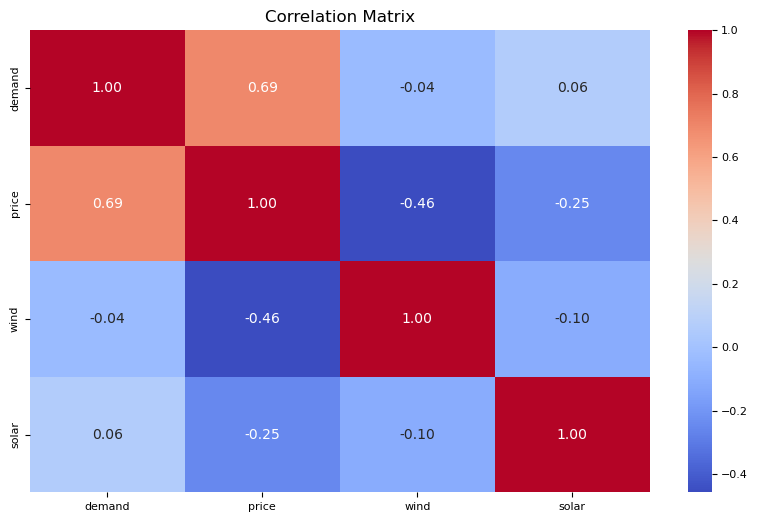

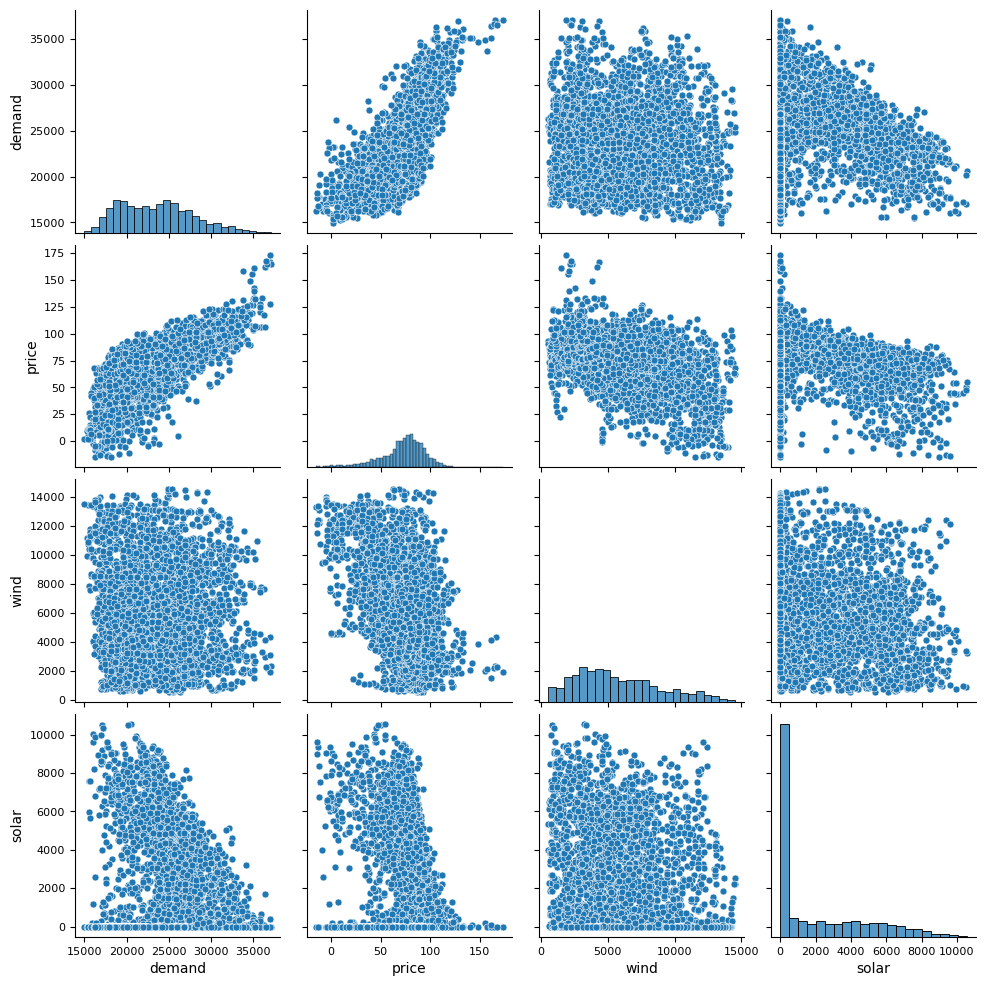

In [23]:
correlation_matrix = filtered_data[['demand', 'price', 'wind', 'solar']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

sns.pairplot(filtered_data[['demand', 'price', 'wind', 'solar']])
plt.show()

In [29]:
ref_data = pd.read_csv("../src/data/processed/reference_day_table.csv")

In [2]:
import pandas as pd
import numpy as np

try:
    actuals = pd.read_csv('../src/data/processed/gb_epex_da_actuals.csv')
    forecast = pd.read_csv('../src/data/processed/reference_day_table.csv')
except FileNotFoundError as e:
    print(f"File not found: {e}")
    exit()

actuals.rename(columns={'da_price': 'actual'}, inplace=True)
forecast.rename(columns={'euclidean_distance': 'forecast'}, inplace=True)

merged_data = pd.merge(actuals, forecast, on='date')


y_true = merged_data['actual']
y_pred = merged_data['forecast']

def compute_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    safe_y_true = np.where(y_true != 0, y_true, 1e-10)
    mape = np.mean(np.abs((y_true - y_pred) / safe_y_true)) * 100
    return mape

def compute_rmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))
    return rmse

mape_value = compute_mape(y_true, y_pred)
rmse_value = compute_rmse(y_true, y_pred)

print(f"MAPE: {mape_value:.2f}%")
print(f"RMSE: {rmse_value:.2f}")


MAPE: 59251507415.54%
RMSE: 70.27


In [1]:
# import pandas as pd
# import numpy as np
# import re
# from datetime import timedelta
# import matplotlib.pyplot as plt

In [2]:
# import os
# import sys
# src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
# sys.path.append(src_path)
# from optimization_logic import *

In [3]:
# SIZE = 100 # MWh (battery capacity)
# POWER_UP = 50 # MW (max discharge power)
# POWER_DOWN = 50 # MW (max charge power)
# TSTEP = 1 # time-step duration (in hours)
# RTE = 0.88 # round trip efficiency; used for charge/discharge efficiency
# CHARGE_EFFICIENCY = np.sqrt(RTE)
# DISCHARGE_EFFICIENCY = np.sqrt(RTE)
# MANUAL_SOC_MIN = 0 # Minimum state-of-charge (MWh)
# MANUAL_SOC_MAX = SIZE # Maximum state-of-charge (MWh)
# INIT_SOC = SIZE / 2 # initial SoC
# END_SOC = 0 # desired end-of-day SoC
# end_soc_limit_type = 'equal_to'
# solution_time_limit = 30 # seconds
# integer_solution = False
# daily_cycle_max = 2.2 # max allowed cycle count

In [4]:
# ref_df = pd.read_csv("../src/data/processed/reference_days_euclidean_table.csv", parse_dates=["date"])



In [5]:
# actual_prices = pd.read_csv("../src/data/processed/gb_epex_da_actuals.csv",
# parse_dates=["date", "dtutc", "dtcet"])

In [6]:
# actual_prices = actual_prices.sort_values("dtutc")

In [24]:
# import re
# import pandas as pd

# # Function to parse 'closest_reference_days' and extract the first date
# def parse_closest_reference_days(cell):
#     try:
#         # Use regex to extract all dates from the string
#         date_matches = re.findall(r"Timestamp\('([^']+)'\)", cell)
#         # Return the first date if available
#         return pd.to_datetime(date_matches[0]) if len(date_matches) > 0 else None
#     except Exception as e:
#         print(f"Error parsing cell: {cell}, error: {e}")
#         return None


In [25]:
# ref_df["closest_reference_day"] = ref_df["closest_reference_days"].apply(parse_closest_reference_days)
# # Check for rows where parsing failed
# missing_ref_days = ref_df[ref_df["closest_reference_day"].isna()]
# print("Rows with missing reference days:")
# print(missing_ref_days)

# # Drop rows with missing reference days (if necessary)
# ref_df = ref_df.dropna(subset=["closest_reference_day"])

# # Ensure all dates are in datetime format
# ref_df["date"] = pd.to_datetime(ref_df["date"])
# ref_df["closest_reference_day"] = pd.to_datetime(ref_df["closest_reference_day"])

Rows with missing reference days:
Empty DataFrame
Columns: [date, closest_reference_days, distance, closest_reference_day]
Index: []


In [13]:
# ref_df["date"] = pd.to_datetime(ref_df["date"])
# ref_df["closest_reference_day"] = pd.to_datetime(ref_df["closest_reference_day"])

In [14]:
# perfect_revenues = []
# reference_revenues = []
# simulation_dates = []

In [26]:
# for idx, row in ref_df.iterrows():
#     target_day = row["date"]
#     ref_day = row["closest_reference_day"]
    
#     print(f"Processing target day: {target_day}, reference day: {ref_day}")
    
#     # Extract hourly DAM prices for target and reference days
#     target_prices_df = actual_prices[actual_prices["date"] == target_day]
#     ref_prices_df = actual_prices[actual_prices["date"] == ref_day]
    
#     if target_prices_df.empty or ref_prices_df.empty:
#         print(f"Missing price data for target day {target_day} or reference day {ref_day}")
#         continue
    
#     # Run simulations (perfect foresight and reference day scheduling)
#     target_price_series = pd.Series(data=target_prices_df["da_price"].values, index=range(len(target_prices_df)))
#     ref_price_series = pd.Series(data=ref_prices_df["da_price"].values, index=range(len(ref_prices_df)))

#     # Perfect foresight simulation
#     battery_pf = day_ahead(
#         size=SIZE,
#         power_up=POWER_UP,
#         power_down=POWER_DOWN,
#         timestep=TSTEP,
#         charge_eff=CHARGE_EFFICIENCY,
#         discharge_eff=DISCHARGE_EFFICIENCY,
#         manual_soc_max=MANUAL_SOC_MAX,
#         manual_soc_min=MANUAL_SOC_MIN,
#         init_soc=INIT_SOC,
#         end_soc=END_SOC,
#         daily_cycle_max=daily_cycle_max,
#         throughput_size=None,
#         solution_time_limit=solution_time_limit,
#         integer_solution=integer_solution,
#         end_soc_limit_type=end_soc_limit_type
#     )
#     _ = battery_pf.solving(dam_actual=target_price_series, dam_fc=None, plot=False)
#     revenue_pf = battery_pf.pnl

#     # Reference day simulation
#     battery_ref = day_ahead(
#         size=SIZE,
#         power_up=POWER_UP,
#         power_down=POWER_DOWN,
#         timestep=TSTEP,
#         charge_eff=CHARGE_EFFICIENCY,
#         discharge_eff=DISCHARGE_EFFICIENCY,
#         manual_soc_max=MANUAL_SOC_MAX,
#         manual_soc_min=MANUAL_SOC_MIN,
#         init_soc=INIT_SOC,
#         end_soc=END_SOC,
#         daily_cycle_max=daily_cycle_max,
#         throughput_size=None,
#         solution_time_limit=solution_time_limit,
#         integer_solution=integer_solution,
#         end_soc_limit_type=end_soc_limit_type
#     )
#     _ = battery_ref.solving(dam_actual=target_price_series, dam_fc=ref_price_series, plot=False)
#     revenue_ref = battery_ref.pnl

#     perfect_revenues.append(revenue_pf)
#     reference_revenues.append(revenue_ref)
#     simulation_dates.append(target_day)

# # Calculate overall ratio if revenues exist
# if perfect_revenues and sum(perfect_revenues) != 0:
#     overall_ratio = (sum(reference_revenues) / sum(perfect_revenues)) * 100
# else:
#     overall_ratio = np.nan

# print(f"Overall Perfect Foresight Ratio (Reference Day Revenue / Perfect Foresight Revenue): {overall_ratio:.2f}%")


Processing target day: 2024-07-30 00:00:00, reference day: 2024-05-31 00:00:00
Processing target day: 2024-07-31 00:00:00, reference day: 2024-06-01 00:00:00
Processing target day: 2024-08-01 00:00:00, reference day: 2024-06-02 00:00:00
Processing target day: 2024-08-02 00:00:00, reference day: 2024-06-03 00:00:00
Processing target day: 2024-08-03 00:00:00, reference day: 2024-06-04 00:00:00
Processing target day: 2024-08-04 00:00:00, reference day: 2024-06-05 00:00:00
Processing target day: 2024-08-05 00:00:00, reference day: 2024-06-06 00:00:00
Processing target day: 2024-08-06 00:00:00, reference day: 2024-06-07 00:00:00
Processing target day: 2024-08-07 00:00:00, reference day: 2024-06-08 00:00:00
Processing target day: 2024-08-08 00:00:00, reference day: 2024-06-09 00:00:00
Processing target day: 2024-08-09 00:00:00, reference day: 2024-06-10 00:00:00
Processing target day: 2024-08-10 00:00:00, reference day: 2024-06-11 00:00:00
Processing target day: 2024-08-11 00:00:00, referenc

In [27]:
# if perfect_revenues and sum(perfect_revenues) != 0:
#     overall_ratio = (sum(reference_revenues) / sum(perfect_revenues)) * 100
# else:
#     overall_ratio = np.nan

# print(f"Overall Perfect Foresight Ratio (Reference Day Revenue / Perfect Foresight Revenue): {overall_ratio:.2f}%")

Overall Perfect Foresight Ratio (Reference Day Revenue / Perfect Foresight Revenue): nan%


In [30]:
# daily_ratios = np.array(reference_revenues) / np.array(perfect_revenues) * 100

# plt.figure(figsize=(10, 5))
# plt.plot(simulation_dates, daily_ratios, marker='o', linestyle='-')
# plt.axhline(y=100, color='red', linestyle='--', label='Perfect Foresight (100%)')
# plt.xlabel("Target Day")
# plt.ylabel("Revenue Ratio (%)")
# plt.title("Daily Revenue Ratio: Reference vs Perfect Foresight")
# plt.legend()
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [29]:
# print(ref_df["closest_reference_days"].head())
